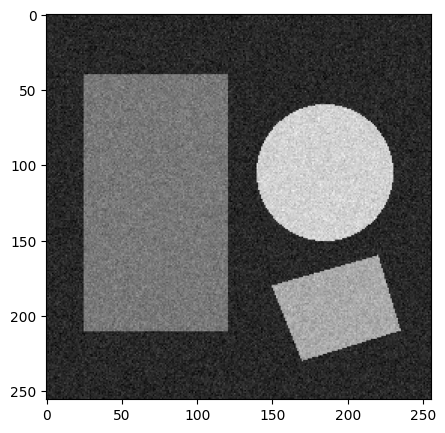

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

plt.figure(figsize=(8, 5))
plt.imshow(image, cmap='gray')
plt.show()

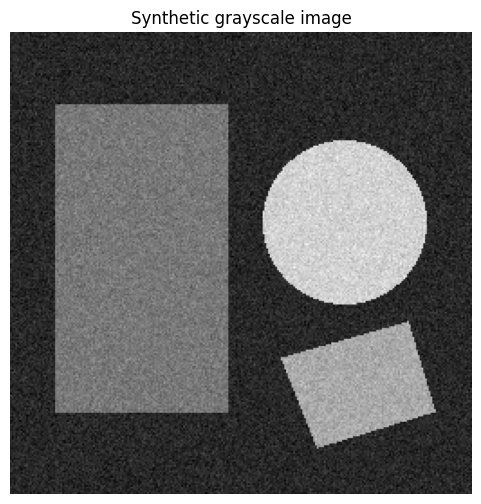

In [2]:
def create_synthetic_image(size=(256, 256), noise_level=12):
    width, height = size
    img = Image.new("L", size, color=40)  # dark background
    draw = ImageDraw.Draw(img)

    # medium rectangle
    draw.rectangle((25, 40, 120, 210), fill=120)

    # bright circle
    draw.ellipse((140, 60, 230, 150), fill=210)

    # slanted bright bar
    draw.polygon([(150, 180), (220, 160), (235, 210), (170, 230)], fill=170)

    arr = np.array(img).astype(np.float32)

    # add noise
    noise = np.random.normal(loc=0, scale=noise_level, size=arr.shape)
    arr = np.clip(arr + noise, 0, 255)

    return arr.astype(np.uint8)

image = create_synthetic_image()

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Synthetic grayscale image")
plt.axis("off")
plt.show()

### Optional: load your own image

If you want to use your own image instead of the synthetic one, uncomment and edit the next cell.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


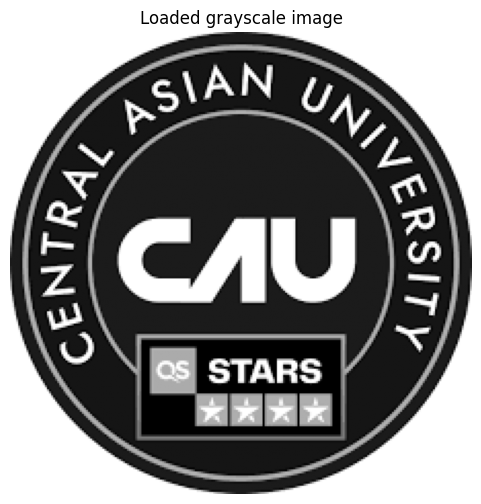

In [6]:
image_path = "/content/drive/MyDrive/cau.png"
image = Image.open(image_path).convert("L")
image = np.array(image)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Loaded grayscale image")
plt.axis("off")
plt.show()

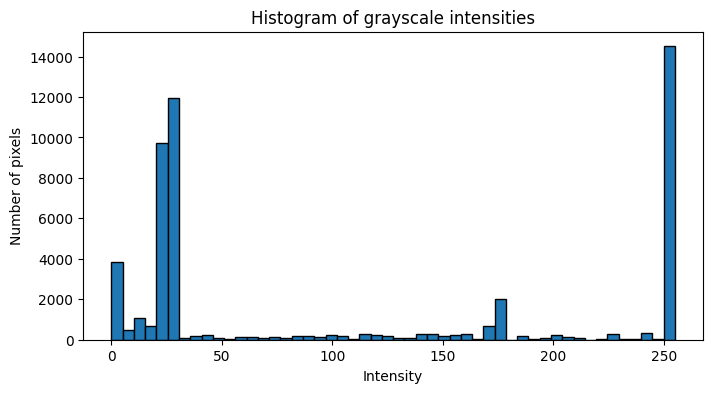

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(image.ravel(), bins=50, edgecolor="black")
plt.title("Histogram of grayscale intensities")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

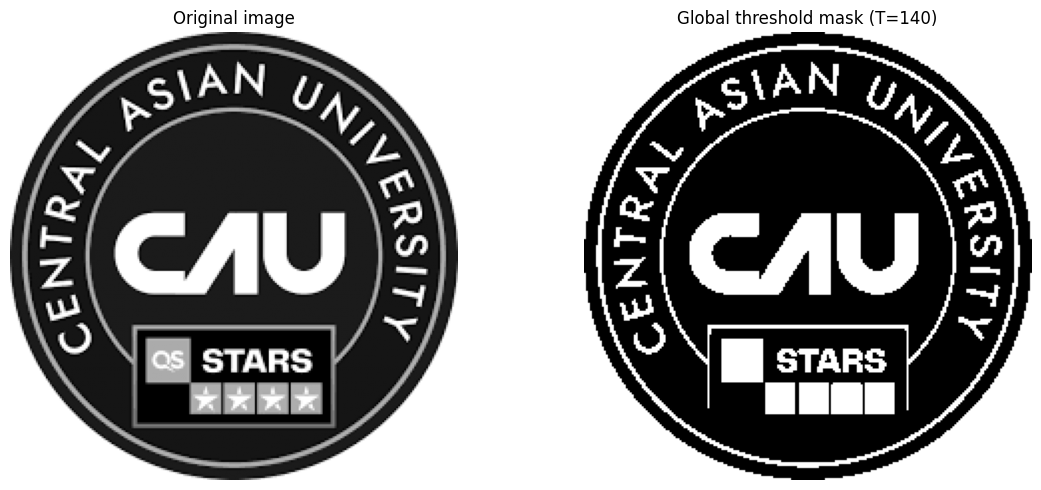

In [8]:
def global_threshold(image, T):
    return (image >= T).astype(np.uint8)

T = 140
mask_global = global_threshold(image, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title(f"Global threshold mask (T={T})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

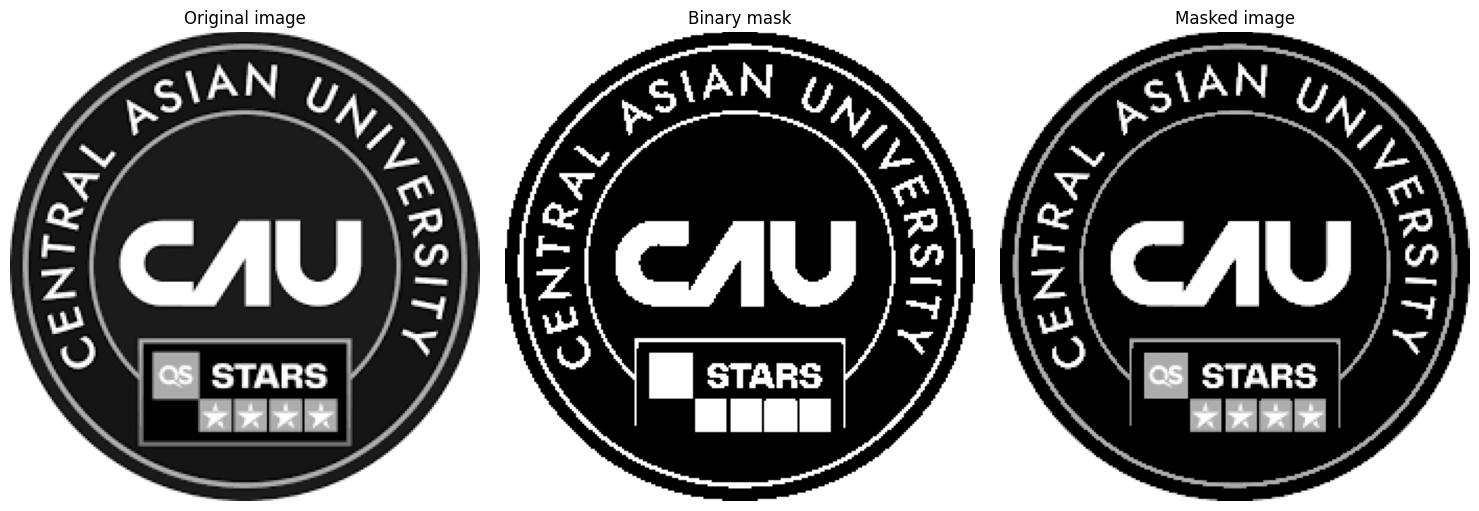

In [9]:
masked_image = image * mask_global

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

axes[2].imshow(masked_image, cmap="gray")
axes[2].set_title("Masked image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

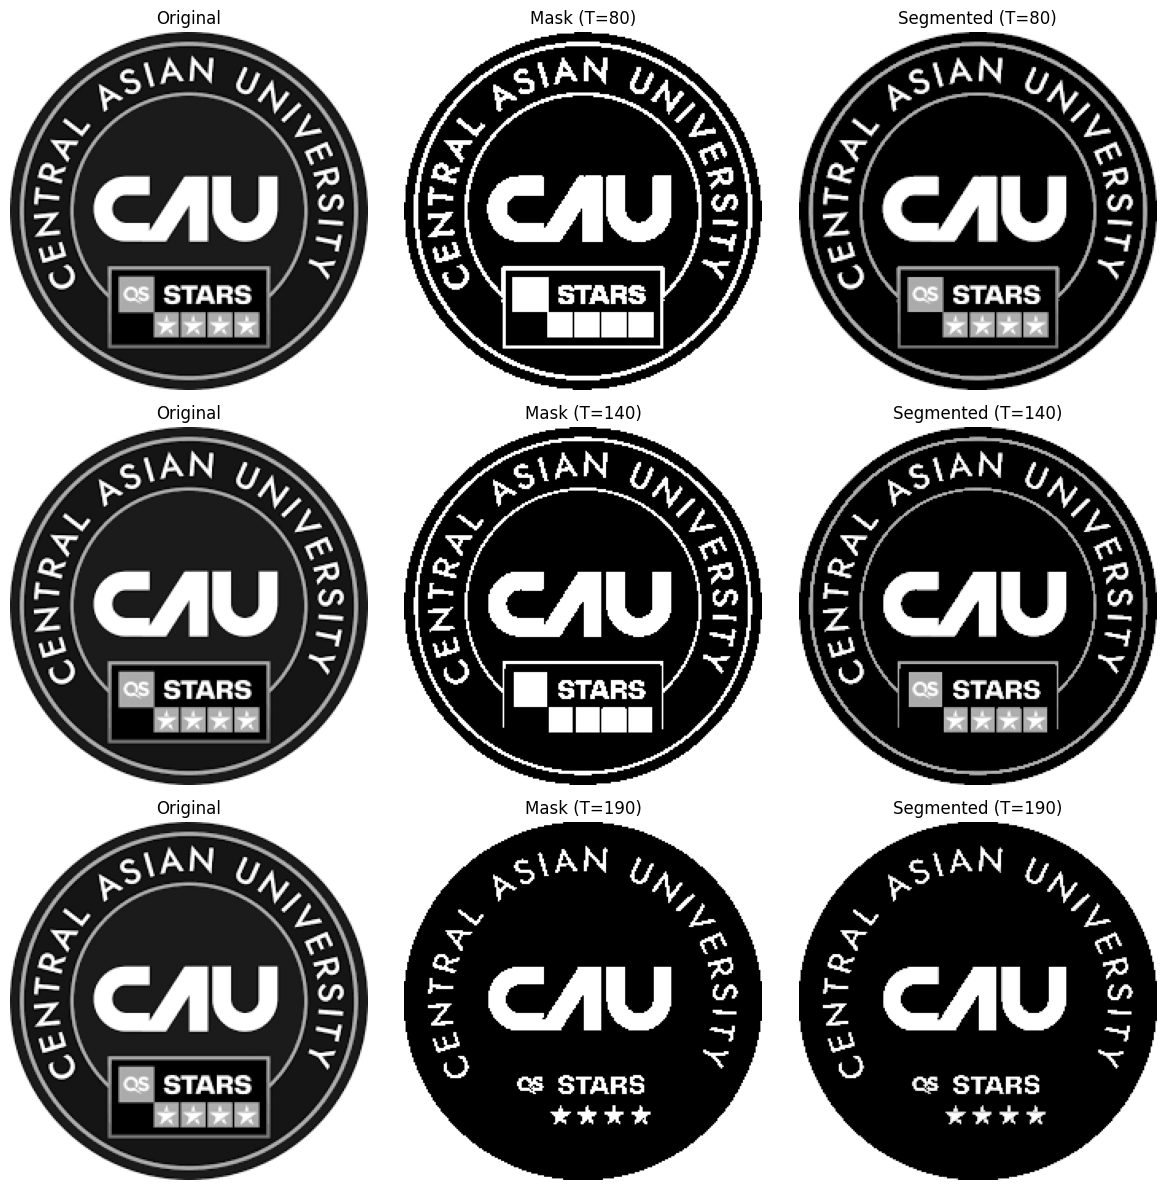

In [10]:
def segment_and_mask(image, threshold):
    mask = (image >= threshold).astype(np.uint8)
    segmented = image * mask
    return mask, segmented

test_thresholds = [80, 140, 190]

fig, axes = plt.subplots(len(test_thresholds), 3, figsize=(12, 12))

for i, thr in enumerate(test_thresholds):
    mask, segmented = segment_and_mask(image, thr)

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Mask (T={thr})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(segmented, cmap="gray")
    axes[i, 2].set_title(f"Segmented (T={thr})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
def convolve2d(image, kernel):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    out = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

Gx = convolve2d(image, sobel_x)
Gy = convolve2d(image, sobel_y)
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

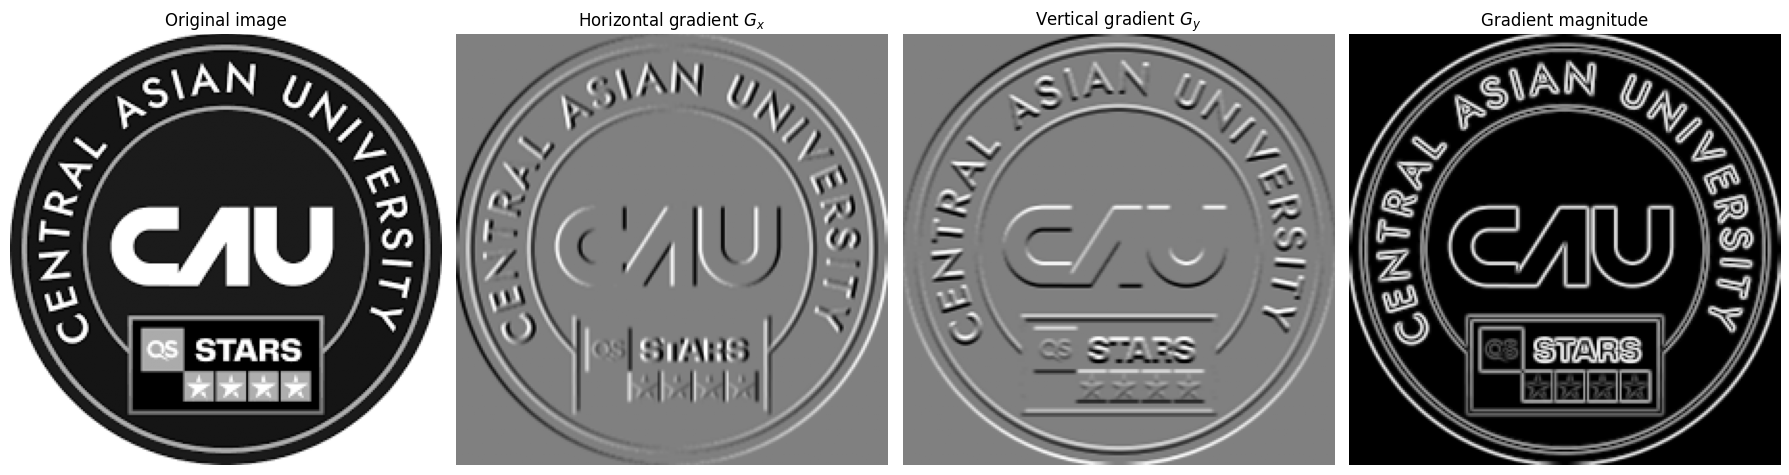

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(Gx, cmap="gray")
axes[1].set_title("Horizontal gradient $G_x$")
axes[1].axis("off")

axes[2].imshow(Gy, cmap="gray")
axes[2].set_title("Vertical gradient $G_y$")
axes[2].axis("off")

axes[3].imshow(gradient_magnitude, cmap="gray")
axes[3].set_title("Gradient magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

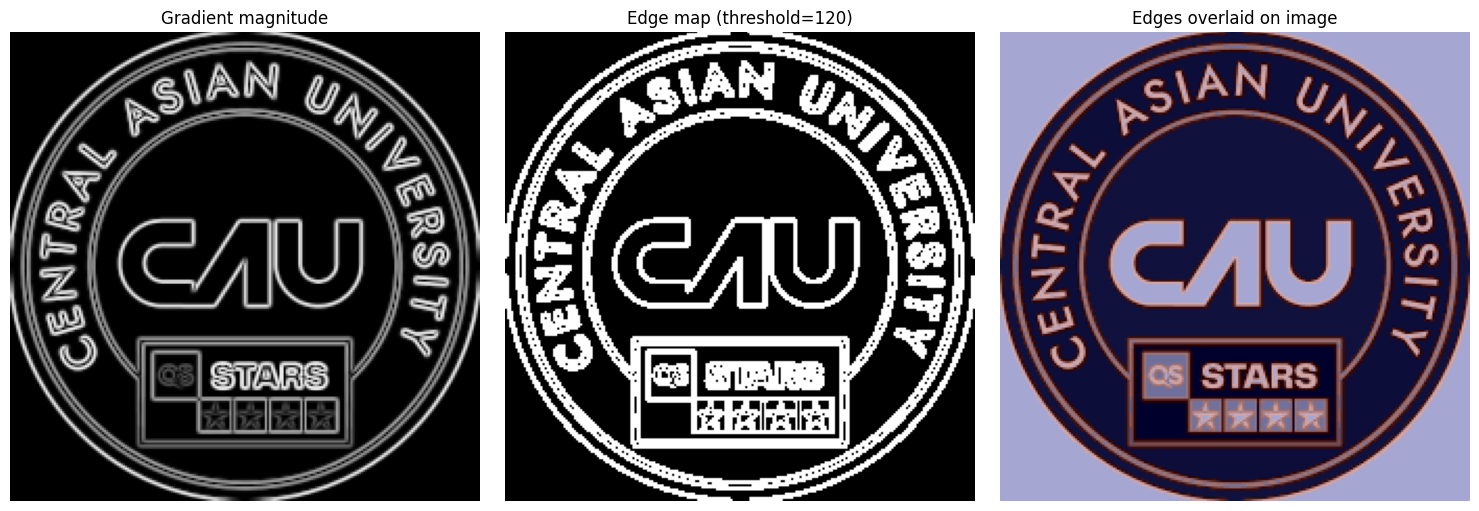

In [13]:
edge_threshold = 120
edges = (gradient_magnitude >= edge_threshold).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gradient_magnitude, cmap="gray")
axes[0].set_title("Gradient magnitude")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title(f"Edge map (threshold={edge_threshold})")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].imshow(edges, cmap="jet", alpha=0.35)
axes[2].set_title("Edges overlaid on image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

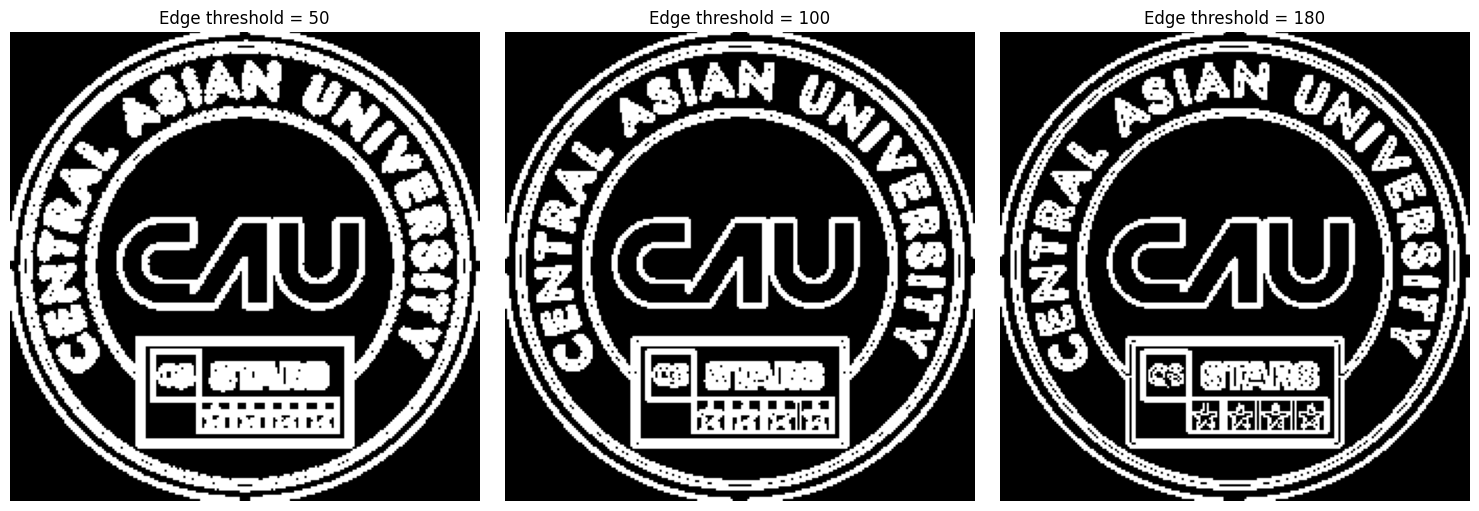

In [14]:
edge_thresholds = [50, 100, 180]

fig, axes = plt.subplots(1, len(edge_thresholds), figsize=(15, 5))

for ax, thr in zip(axes, edge_thresholds):
    e = (gradient_magnitude >= thr).astype(np.uint8)
    ax.imshow(e, cmap="gray")
    ax.set_title(f"Edge threshold = {thr}")
    ax.axis("off")

plt.tight_layout()
plt.show()